In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# =========================================================
# HISTOGRAM OF NEURON ACTIVATIONS (Cats vs Dogs)
# Penultimate + Final Layer
# =========================================================

# -------------------------------
# SETTINGS
# -------------------------------
THRESHOLD = 1.0   # Change freely (try 0.5, 1.0, 2.0)


# -------------------------------
# STORAGE
# -------------------------------
penult_cats = []
penult_dogs = []

final_cats = []
final_dogs = []

current_label = None


# -------------------------------
# HOOKS
# -------------------------------
def penultimate_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1).numpy()[0]

    if current_label == "cats":
        penult_cats.append(out)
    else:
        penult_dogs.append(out)


def final_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1).numpy()[0]

    if current_label == "cats":
        final_cats.append(out)
    else:
        final_dogs.append(out)


hook1 = model.avgpool.register_forward_hook(penultimate_hook)
hook2 = model.fc.register_forward_hook(final_hook)


# -------------------------------
# FORWARD PASS
# -------------------------------
with torch.no_grad():
    for path, cls in zip(image_paths, image_classes):

        current_label = cls
        img = load_image(path).to(device)
        _ = model(img)


hook1.remove()
hook2.remove()


# -------------------------------
# Convert To Arrays
# -------------------------------
penult_cats = np.vstack(penult_cats)
penult_dogs = np.vstack(penult_dogs)

final_cats = np.vstack(final_cats)
final_dogs = np.vstack(final_dogs)


# =========================================================
# HISTOGRAM 1 — RAW ACTIVATION VALUES
# =========================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(penult_cats.flatten(), bins=100, alpha=0.5, label="Cats")
plt.hist(penult_dogs.flatten(), bins=100, alpha=0.5, label="Dogs")
plt.title("Penultimate Layer Activation Distribution")
plt.legend()

plt.subplot(1,2,2)
plt.hist(final_cats.flatten(), bins=100, alpha=0.5, label="Cats")
plt.hist(final_dogs.flatten(), bins=100, alpha=0.5, label="Dogs")
plt.title("Final Layer Activation Distribution")
plt.legend()

plt.show()


# =========================================================
# HISTOGRAM 2 — THRESHOLDED NEURON COUNTS PER IMAGE
# =========================================================

penult_cat_counts = (penult_cats > THRESHOLD).sum(axis=1)
penult_dog_counts = (penult_dogs > THRESHOLD).sum(axis=1)

final_cat_counts = (final_cats > THRESHOLD).sum(axis=1)
final_dog_counts = (final_dogs > THRESHOLD).sum(axis=1)


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(penult_cat_counts, bins=40, alpha=0.5, label="Cats")
plt.hist(penult_dog_counts, bins=40, alpha=0.5, label="Dogs")
plt.title(f"Penultimate — # Active Neurons (> {THRESHOLD})")
plt.legend()

plt.subplot(1,2,2)
plt.hist(final_cat_counts, bins=40, alpha=0.5, label="Cats")
plt.hist(final_dog_counts, bins=40, alpha=0.5, label="Dogs")
plt.title(f"Final — # Active Neurons (> {THRESHOLD})")
plt.legend()

plt.show()


Total images: 200
Penultimate shape: (100, 2048) (100, 2048)
Final shape: (100, 1000) (100, 1000)


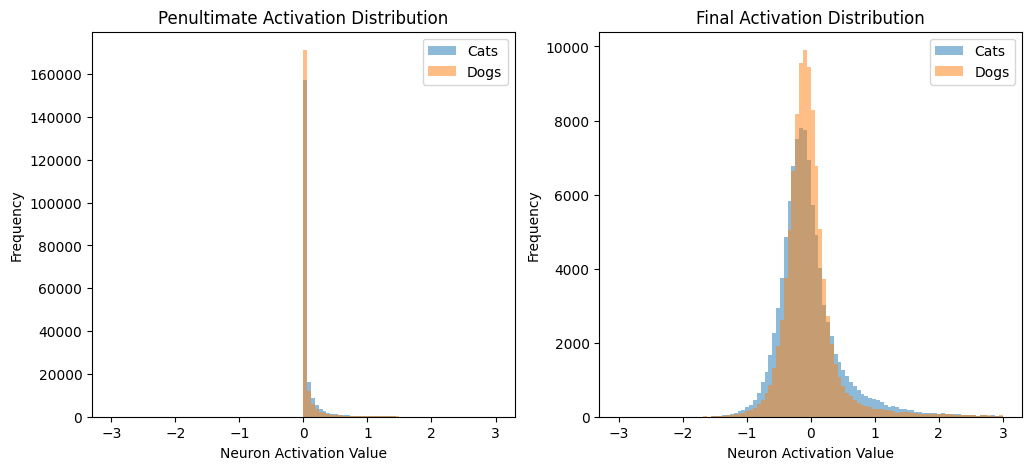

In [4]:
# =========================================================
# HISTOGRAM OF NEURON ACTIVATIONS — Data_100 Cats vs Dogs
# Penultimate (avgpool) + Final (fc)
# =========================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image


# -------------------------------
# SETTINGS
# -------------------------------
THRESHOLD = 1.0
base_folder = "/Users/jaeeponde/Thesis/Data_100"


# -------------------------------
# MODEL
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model = model.to(device)
model.eval()


# -------------------------------
# TRANSFORM
# -------------------------------
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


def load_image(path):
    img = Image.open(path).convert("RGB")
    return transform(img).unsqueeze(0)


# -------------------------------
# LOAD DATASET PATHS
# -------------------------------
image_paths = []
image_classes = []

for label in ["Cats", "Dogs"]:
    folder = os.path.join(base_folder, label)

    if os.path.exists(folder):
        for f in os.listdir(folder):
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                image_paths.append(os.path.join(folder, f))
                image_classes.append(label.lower())

print("Total images:", len(image_paths))


# -------------------------------
# STORAGE
# -------------------------------
penult_cats = []
penult_dogs = []
final_cats = []
final_dogs = []

current_label = None


# -------------------------------
# HOOKS
# -------------------------------
def penultimate_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1).numpy()[0]

    if current_label == "cats":
        penult_cats.append(out)
    else:
        penult_dogs.append(out)


def final_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1).numpy()[0]

    if current_label == "cats":
        final_cats.append(out)
    else:
        final_dogs.append(out)


hook1 = model.avgpool.register_forward_hook(penultimate_hook)
hook2 = model.fc.register_forward_hook(final_hook)


# -------------------------------
# FORWARD PASS
# -------------------------------
with torch.no_grad():
    for path, cls in zip(image_paths, image_classes):
        current_label = cls
        img = load_image(path).to(device)
        _ = model(img)

hook1.remove()
hook2.remove()


# -------------------------------
# ARRAYS
# -------------------------------
penult_cats = np.vstack(penult_cats)
penult_dogs = np.vstack(penult_dogs)
final_cats = np.vstack(final_cats)
final_dogs = np.vstack(final_dogs)


print("Penultimate shape:", penult_cats.shape, penult_dogs.shape)
print("Final shape:", final_cats.shape, final_dogs.shape)


# =========================================================
# HISTOGRAM 1 — RAW ACTIVATIONS (Zoomed to [-3, 3])
# =========================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(penult_cats.flatten(), bins=100, alpha=0.5, label="Cats", range=(-3,3))
plt.hist(penult_dogs.flatten(), bins=100, alpha=0.5, label="Dogs", range=(-3,3))
plt.title("Penultimate Activation Distribution")
plt.xlabel("Neuron Activation Value")
plt.ylabel("Frequency")
plt.legend()

plt.subplot(1,2,2)
plt.hist(final_cats.flatten(), bins=100, alpha=0.5, label="Cats", range=(-3,3))
plt.hist(final_dogs.flatten(), bins=100, alpha=0.5, label="Dogs", range=(-3,3))
plt.title("Final Activation Distribution")
plt.xlabel("Neuron Activation Value")
plt.ylabel("Frequency")
plt.legend()

plt.show()


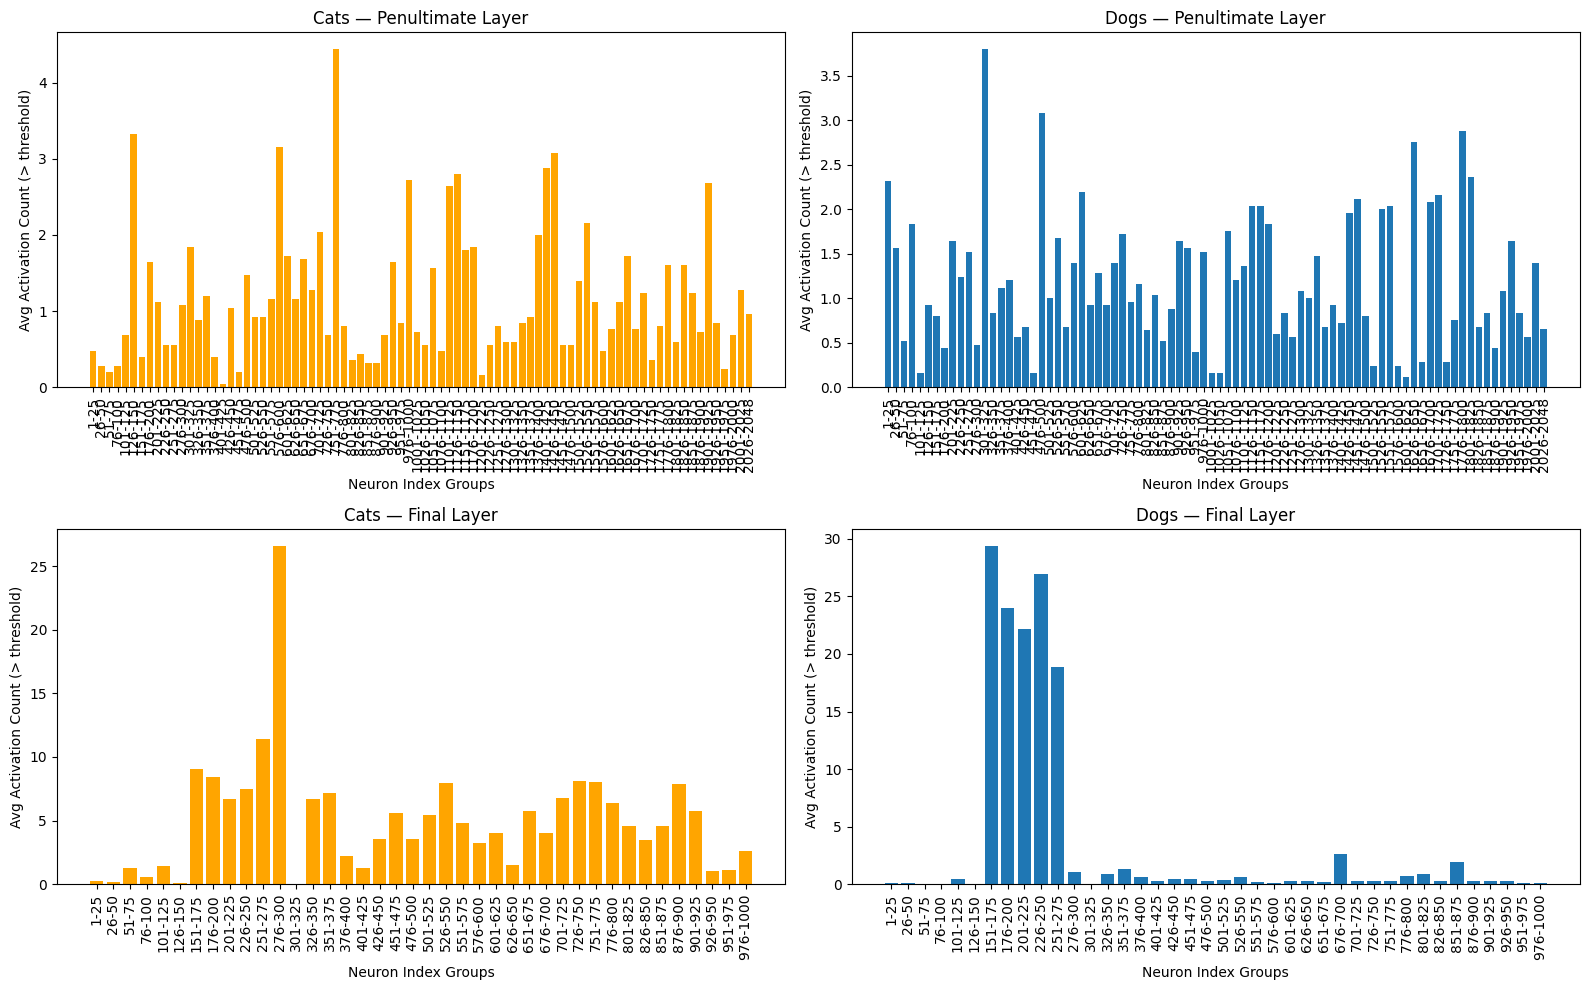

In [16]:
# =========================================================
# HISTOGRAM 2 — SEPARATE CATS vs DOGS
# Neuron Group Activation Frequency
# =========================================================

THRESHOLD = 1.0
GROUP_SIZE = 25


# -------------------------------
# Binary activation matrices
# -------------------------------
penult_cats_active = penult_cats > THRESHOLD
penult_dogs_active = penult_dogs > THRESHOLD

final_cats_active = final_cats > THRESHOLD
final_dogs_active = final_dogs > THRESHOLD


# -------------------------------
# Activation frequency per neuron
# (Across all images of that class)
# -------------------------------
penult_cats_freq = penult_cats_active.sum(axis=0)
penult_dogs_freq = penult_dogs_active.sum(axis=0)

final_cats_freq = final_cats_active.sum(axis=0)
final_dogs_freq = final_dogs_active.sum(axis=0)


# -------------------------------
# Group neurons
# -------------------------------
def group_neurons(freq_array, group_size):
    n_neurons = len(freq_array)
    groups = []

    for i in range(0, n_neurons, group_size):
        groups.append(freq_array[i:i+group_size].mean())

    return np.array(groups)


penult_cats_grouped = group_neurons(penult_cats_freq, GROUP_SIZE)
penult_dogs_grouped = group_neurons(penult_dogs_freq, GROUP_SIZE)

final_cats_grouped = group_neurons(final_cats_freq, GROUP_SIZE)
final_dogs_grouped = group_neurons(final_dogs_freq, GROUP_SIZE)


# -------------------------------
# X Labels
# -------------------------------
def make_labels(n_neurons, group_size):
    labels = []
    for i in range(0, n_neurons, group_size):
        labels.append(f"{i+1}-{min(i+group_size, n_neurons)}")
    return labels


penult_labels = make_labels(len(penult_cats_freq), GROUP_SIZE)
final_labels = make_labels(len(final_cats_freq), GROUP_SIZE)


# =========================================================
# PLOTS — 4 HISTOGRAMS
# =========================================================

plt.figure(figsize=(16,10))


# -------------------------------
# Penultimate Cats
# -------------------------------
plt.subplot(2,2,1)
plt.bar(range(len(penult_cats_grouped)), penult_cats_grouped, color="orange")
plt.xticks(range(len(penult_labels)), penult_labels, rotation=90)
plt.title("Cats — Penultimate Layer")
plt.xlabel("Neuron Index Groups")
plt.ylabel("Avg Activation Count (> threshold)")


# -------------------------------
# Penultimate Dogs
# -------------------------------
plt.subplot(2,2,2)
plt.bar(range(len(penult_dogs_grouped)), penult_dogs_grouped)
plt.xticks(range(len(penult_labels)), penult_labels, rotation=90)
plt.title("Dogs — Penultimate Layer")
plt.xlabel("Neuron Index Groups")
plt.ylabel("Avg Activation Count (> threshold)")


# -------------------------------
# Final Cats
# -------------------------------
plt.subplot(2,2,3)
plt.bar(range(len(final_cats_grouped)), final_cats_grouped, color="orange")
plt.xticks(range(len(final_labels)), final_labels, rotation=90)
plt.title("Cats — Final Layer")
plt.xlabel("Neuron Index Groups")
plt.ylabel("Avg Activation Count (> threshold)")


# -------------------------------
# Final Dogs
# -------------------------------
plt.subplot(2,2,4)
plt.bar(range(len(final_dogs_grouped)), final_dogs_grouped)
plt.xticks(range(len(final_labels)), final_labels, rotation=90)
plt.title("Dogs — Final Layer")
plt.xlabel("Neuron Index Groups")
plt.ylabel("Avg Activation Count (> threshold)")


plt.tight_layout()
plt.show()


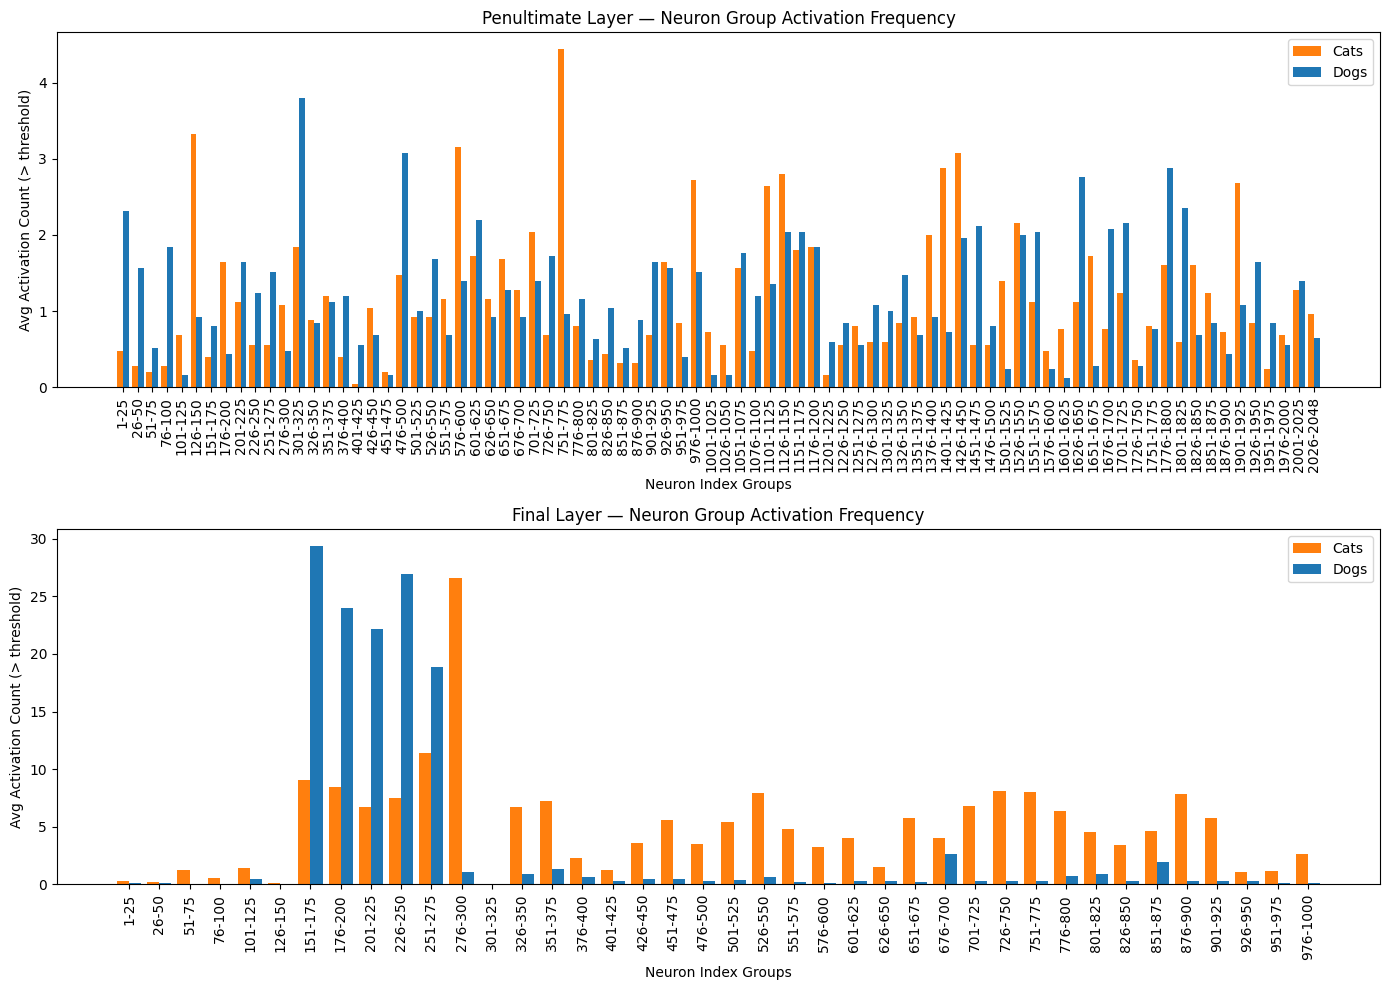

In [17]:
# =========================================================
# SUPERIMPOSED PLOTS — Cats vs Dogs Together
# =========================================================

plt.figure(figsize=(14,10))

bar_width = 0.4
x_penult = np.arange(len(penult_cats_grouped))
x_final = np.arange(len(final_cats_grouped))


# -------------------------------
# Penultimate Overlay
# -------------------------------
plt.subplot(2,1,1)

plt.bar(
    x_penult - bar_width/2,
    penult_cats_grouped,
    width=bar_width,
    color="tab:orange",
    label="Cats"
)

plt.bar(
    x_penult + bar_width/2,
    penult_dogs_grouped,
    width=bar_width,
    color="tab:blue",
    label="Dogs"
)

plt.xticks(x_penult, penult_labels, rotation=90)
plt.title("Penultimate Layer — Neuron Group Activation Frequency")
plt.xlabel("Neuron Index Groups")
plt.ylabel("Avg Activation Count (> threshold)")
plt.legend()


# -------------------------------
# Final Overlay
# -------------------------------
plt.subplot(2,1,2)

plt.bar(
    x_final - bar_width/2,
    final_cats_grouped,
    width=bar_width,
    color="tab:orange",
    label="Cats"
)

plt.bar(
    x_final + bar_width/2,
    final_dogs_grouped,
    width=bar_width,
    color="tab:blue",
    label="Dogs"
)

plt.xticks(x_final, final_labels, rotation=90)
plt.title("Final Layer — Neuron Group Activation Frequency")
plt.xlabel("Neuron Index Groups")
plt.ylabel("Avg Activation Count (> threshold)")
plt.legend()


plt.tight_layout()
plt.show()


In [9]:
# =========================================================
# INDEPENDENT GRANDMOTHER NEURON DETECTION
# =========================================================

THRESHOLD = 1.0


# -------------------------------
# CAT GRANDMOTHER SCORE
# -------------------------------
cat_mean = penult_cats.mean(axis=0)
cat_fire_rate = (penult_cats > THRESHOLD).mean(axis=0)

cat_grandmother_score = cat_mean * cat_fire_rate


# -------------------------------
# DOG GRANDMOTHER SCORE
# -------------------------------
dog_mean = penult_dogs.mean(axis=0)
dog_fire_rate = (penult_dogs > THRESHOLD).mean(axis=0)

dog_grandmother_score = dog_mean * dog_fire_rate


# -------------------------------
# TOP NEURONS
# -------------------------------
TOP_K = 20

top_cat_neurons = np.argsort(cat_grandmother_score)[-TOP_K:]
top_dog_neurons = np.argsort(dog_grandmother_score)[-TOP_K:]


print("\nTop CAT Independent Grandmother Neurons:")
print(top_cat_neurons)

print("\nTop DOG Independent Grandmother Neurons:")
print(top_dog_neurons)



Top CAT Independent Grandmother Neurons:
[1431 1139 1168 1376  618  712 1400 1833  576  578 1419  310  663 1433
 1534  127  990 1118 1917  754]

Top DOG Independent Grandmother Neurons:
[ 667 1640 1347 1788  747  256 2019  212 1721  578  603 1928 1534 1687
 1162   17  483 1808 1646  310]


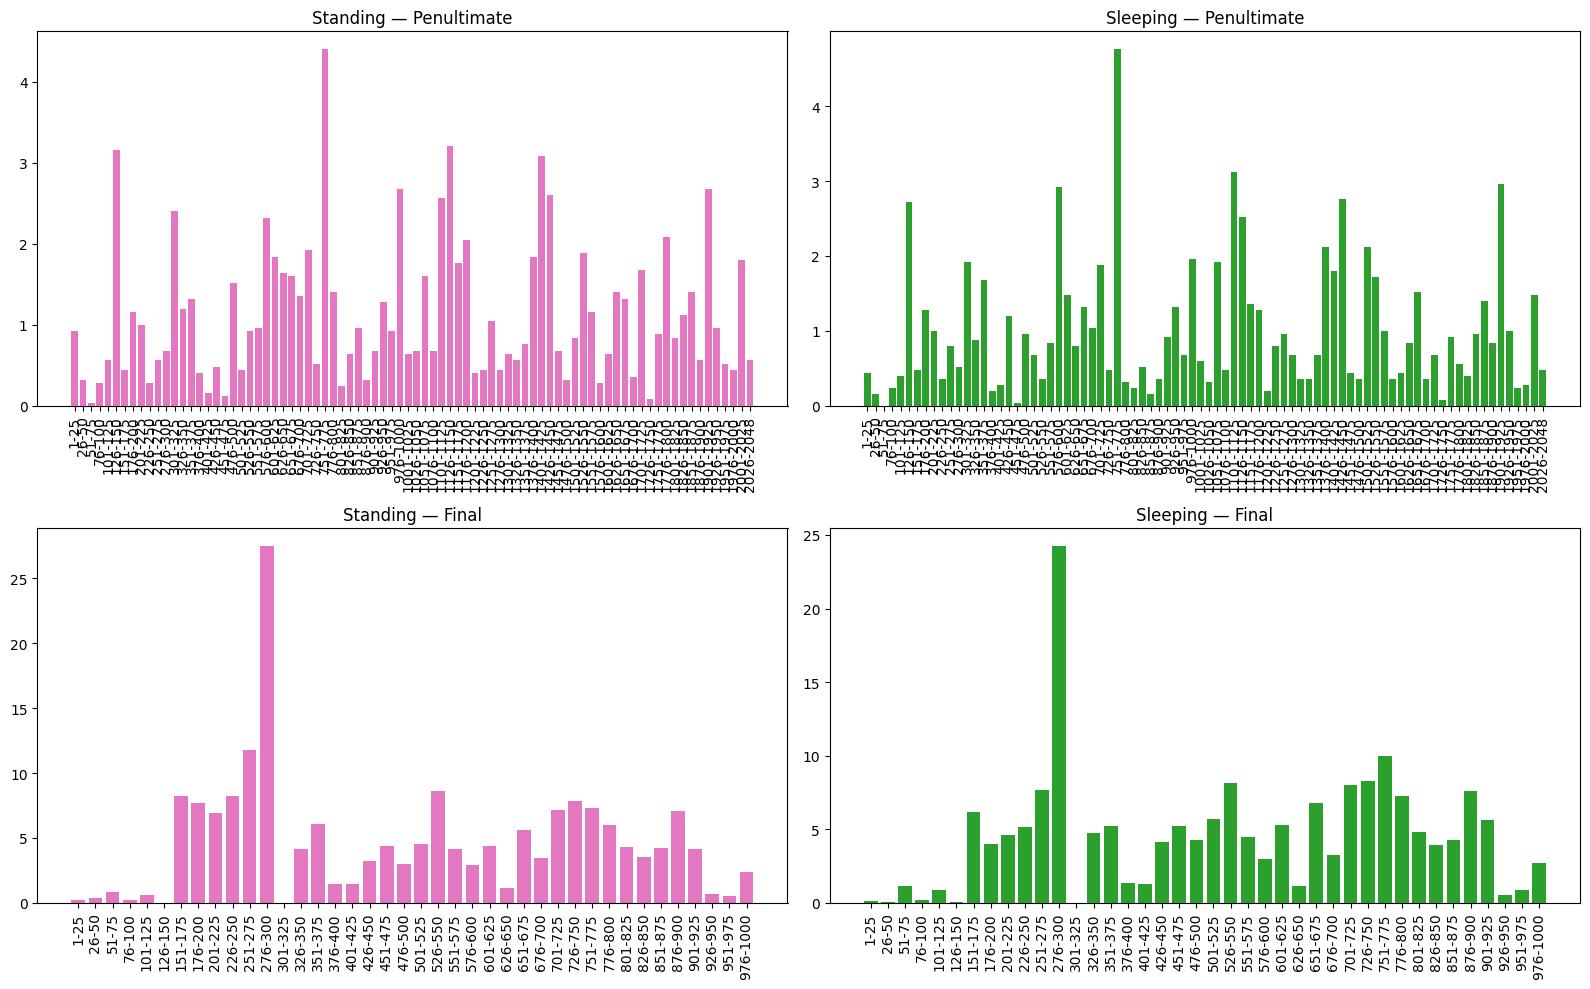

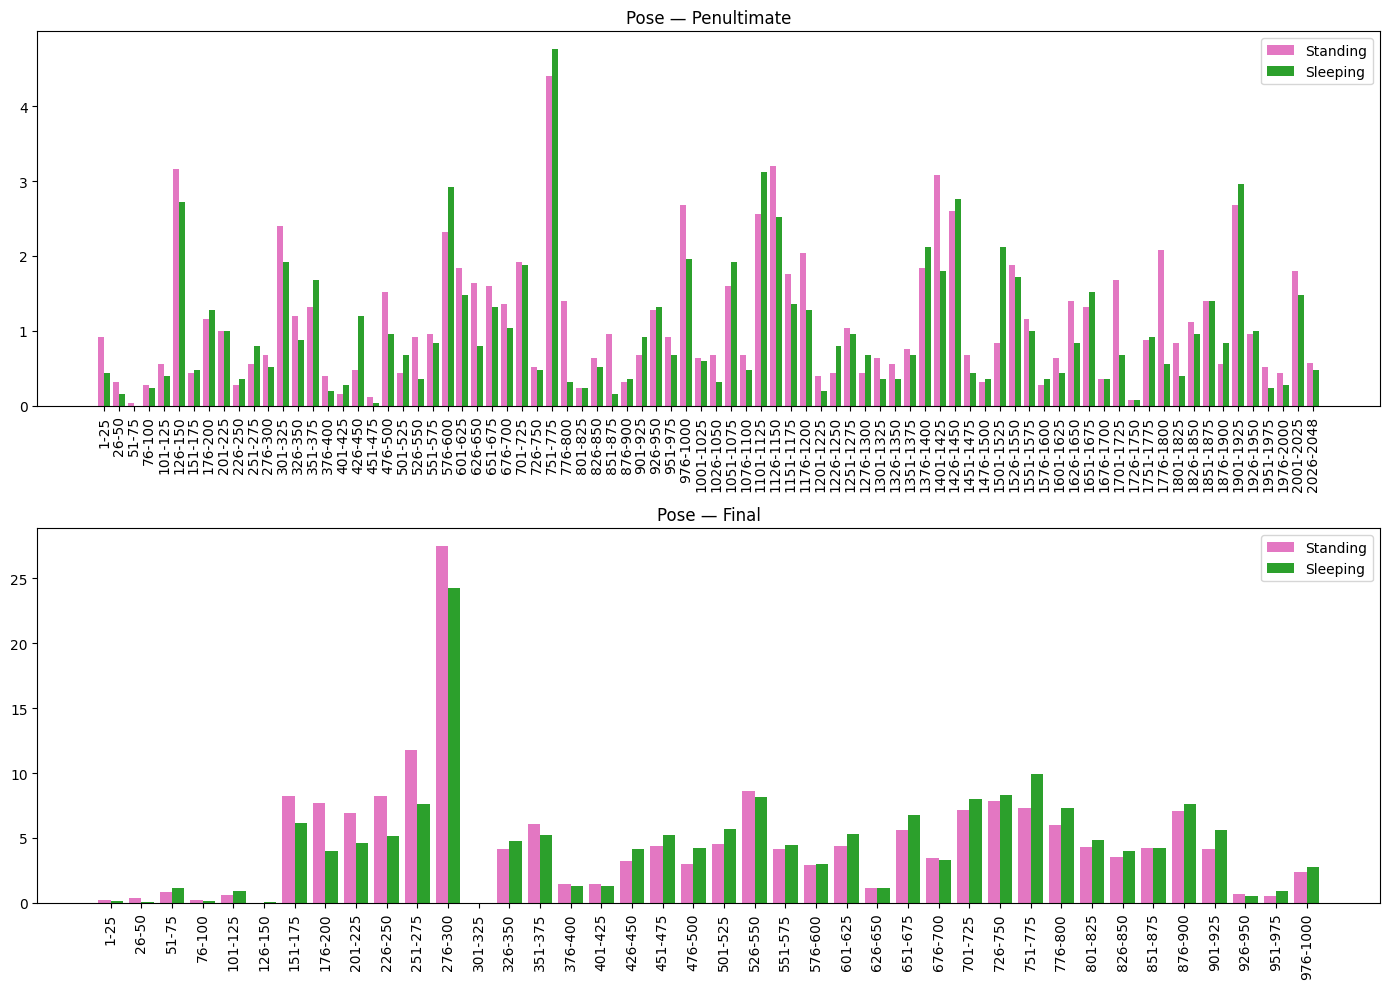

In [20]:
# =========================================================
# CAT POSE — Standing vs Sleeping
# Full Pipeline + Overlay + Non Overlay
# =========================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image


# -------------------------------
# SETTINGS
# -------------------------------
BASE_FOLDER = "/Users/jaeeponde/Thesis/Pose_100"
THRESHOLD = 1.0
GROUP_SIZE = 25


# -------------------------------
# MODEL
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model = model.to(device)
model.eval()


# -------------------------------
# TRANSFORM
# -------------------------------
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


def load_image(path):
    img = Image.open(path).convert("RGB")
    return transform(img).unsqueeze(0)


# -------------------------------
# LOAD DATA
# -------------------------------
image_paths = []
image_labels = []

for label in ["Standing", "Sleeping"]:
    folder = os.path.join(BASE_FOLDER, label)

    for f in os.listdir(folder):
        if f.lower().endswith((".jpg",".png",".jpeg")):
            image_paths.append(os.path.join(folder, f))
            image_labels.append(label.lower())


# -------------------------------
# STORAGE
# -------------------------------
penult_standing = []
penult_sleeping = []

final_standing = []
final_sleeping = []

current_label = None


# -------------------------------
# HOOKS
# -------------------------------
def penultimate_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1).numpy()[0]

    if current_label == "standing":
        penult_standing.append(out)
    else:
        penult_sleeping.append(out)


def final_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1).numpy()[0]

    if current_label == "standing":
        final_standing.append(out)
    else:
        final_sleeping.append(out)


h1 = model.avgpool.register_forward_hook(penultimate_hook)
h2 = model.fc.register_forward_hook(final_hook)


# -------------------------------
# FORWARD PASS
# -------------------------------
with torch.no_grad():
    for path, cls in zip(image_paths, image_labels):
        current_label = cls
        img = load_image(path).to(device)
        _ = model(img)

h1.remove()
h2.remove()


# -------------------------------
# ARRAYS
# -------------------------------
penult_standing = np.vstack(penult_standing)
penult_sleeping = np.vstack(penult_sleeping)

final_standing = np.vstack(final_standing)
final_sleeping = np.vstack(final_sleeping)


# -------------------------------
# GROUPING LOGIC
# -------------------------------
def group_neurons(freq_array, group_size):
    groups = []
    for i in range(0, len(freq_array), group_size):
        groups.append(freq_array[i:i+group_size].mean())
    return np.array(groups)


def make_labels(n_neurons, group_size):
    labels = []
    for i in range(0, n_neurons, group_size):
        labels.append(f"{i+1}-{min(i+group_size,n_neurons)}")
    return labels


# -------------------------------
# FREQUENCIES
# -------------------------------
penult_stand_freq = (penult_standing > THRESHOLD).sum(axis=0)
penult_sleep_freq = (penult_sleeping > THRESHOLD).sum(axis=0)

final_stand_freq = (final_standing > THRESHOLD).sum(axis=0)
final_sleep_freq = (final_sleeping > THRESHOLD).sum(axis=0)


penult_stand_grp = group_neurons(penult_stand_freq, GROUP_SIZE)
penult_sleep_grp = group_neurons(penult_sleep_freq, GROUP_SIZE)

final_stand_grp = group_neurons(final_stand_freq, GROUP_SIZE)
final_sleep_grp = group_neurons(final_sleep_freq, GROUP_SIZE)


penult_labels = make_labels(len(penult_stand_freq), GROUP_SIZE)
final_labels = make_labels(len(final_stand_freq), GROUP_SIZE)


# =========================================================
# NON OVERLAY PLOTS
# =========================================================
plt.figure(figsize=(16,10))

plt.subplot(2,2,1)
plt.bar(range(len(penult_stand_grp)), penult_stand_grp, color="tab:pink")
plt.xticks(range(len(penult_labels)), penult_labels, rotation=90)
plt.title("Standing — Penultimate")

plt.subplot(2,2,2)
plt.bar(range(len(penult_sleep_grp)), penult_sleep_grp, color="tab:green")
plt.xticks(range(len(penult_labels)), penult_labels, rotation=90)
plt.title("Sleeping — Penultimate")

plt.subplot(2,2,3)
plt.bar(range(len(final_stand_grp)), final_stand_grp, color="tab:pink")
plt.xticks(range(len(final_labels)), final_labels, rotation=90)
plt.title("Standing — Final")

plt.subplot(2,2,4)
plt.bar(range(len(final_sleep_grp)), final_sleep_grp, color="tab:green")
plt.xticks(range(len(final_labels)), final_labels, rotation=90)
plt.title("Sleeping — Final")

plt.tight_layout()
plt.show()


# =========================================================
# OVERLAY PLOTS
# =========================================================
plt.figure(figsize=(14,10))

bar_width = 0.4
x_penult = np.arange(len(penult_stand_grp))
x_final = np.arange(len(final_stand_grp))


plt.subplot(2,1,1)
plt.bar(x_penult-bar_width/2, penult_stand_grp, width=bar_width, color="tab:pink", label="Standing")
plt.bar(x_penult+bar_width/2, penult_sleep_grp, width=bar_width, color="tab:green", label="Sleeping")
plt.xticks(x_penult, penult_labels, rotation=90)
plt.title("Pose — Penultimate")
plt.legend()


plt.subplot(2,1,2)
plt.bar(x_final-bar_width/2, final_stand_grp, width=bar_width, color="tab:pink", label="Standing")
plt.bar(x_final+bar_width/2, final_sleep_grp, width=bar_width, color="tab:green", label="Sleeping")
plt.xticks(x_final, final_labels, rotation=90)
plt.title("Pose — Final")
plt.legend()

plt.tight_layout()
plt.show()


Total images: 200
Classes: {'standing', 'sleeping'}


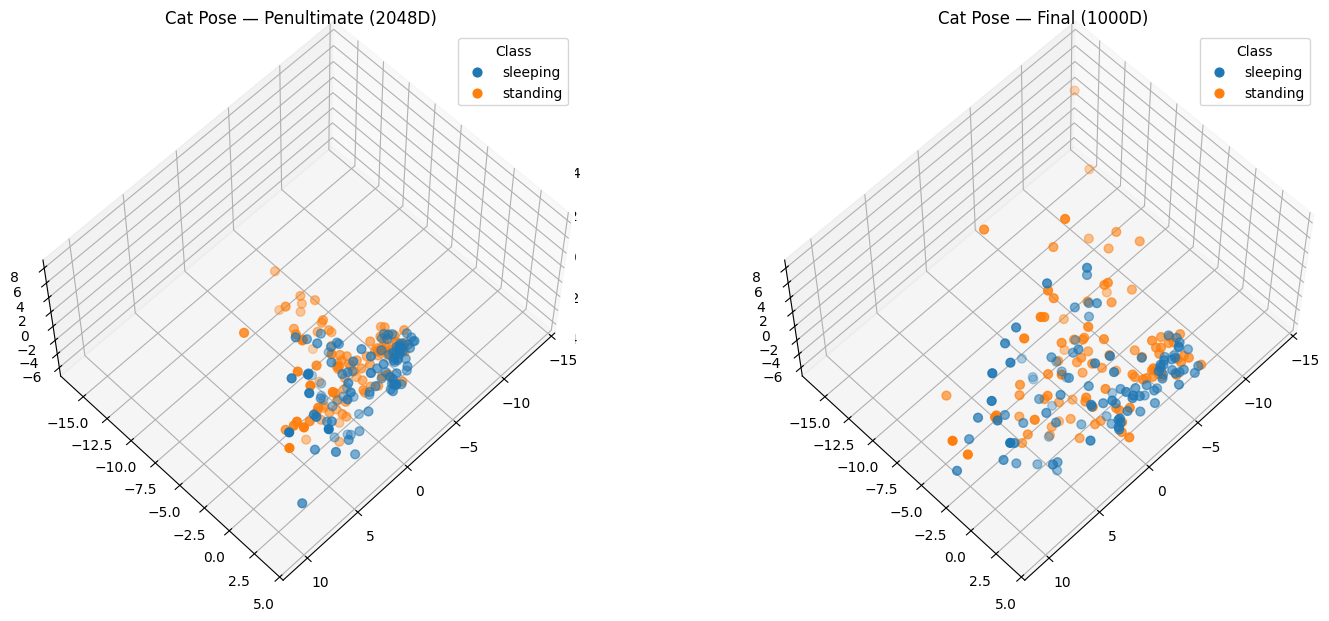

In [22]:
# =========================================================
# ALL-IN-ONE: ResNet50 → Embeddings → PCA → Side-by-Side Plot
# =========================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# ================================
# DATASET: CAT POSE
# ================================
base_folder = "/Users/jaeeponde/Thesis/Pose_100"

image_paths = []
image_classes = []

class_names = sorted(os.listdir(base_folder))

for cls in class_names:
    folder = os.path.join(base_folder, cls)

    if not os.path.isdir(folder):
        continue

    for f in os.listdir(folder):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(folder, f))
            image_classes.append(cls.lower())

image_paths = image_paths[:300]
image_classes = image_classes[:300]

print("Total images:", len(image_paths))
print("Classes:", set(image_classes))


# ================================
# HOOKS
# ================================
penultimate_outputs = []
final_outputs = []
labels_store = []

current_label = None


def penultimate_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1)
    penultimate_outputs.append(out.numpy()[0])
    labels_store.append(current_label)

def final_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1)
    final_outputs.append(out.numpy()[0])

hook1 = model.avgpool.register_forward_hook(penultimate_hook)
hook2 = model.fc.register_forward_hook(final_hook)


# ================================
# Forward Pass
# ================================
with torch.no_grad():
    for path, cls in zip(image_paths, image_classes):
        current_label = cls
        img = load_image(path).to(device)
        _ = model(img)

hook1.remove()
hook2.remove()


# ================================
# PCA
# ================================
penultimate_embeddings = np.vstack(penultimate_outputs)
final_embeddings = np.vstack(final_outputs)

labels = labels_store

pca_penult = PCA(n_components=3)
penult_3d = pca_penult.fit_transform(penultimate_embeddings)

pca_final = PCA(n_components=3)
emb_3d = pca_final.fit_transform(final_embeddings)


# ================================
# COLORS
# ================================
unique_labels = sorted(list(set(labels)))
color_map = {l:i for i,l in enumerate(unique_labels)}

colors = [color_map[l] for l in labels]


# ================================
# PLOT
# ================================
fig = plt.figure(figsize=(16,6))

ax2 = fig.add_subplot(121, projection='3d')
labels_np = np.array(labels)

# -------- Penultimate Plot --------
for label in unique_labels:
    mask = labels_np == label

    ax2.scatter(
        penult_3d[mask, 0],
        penult_3d[mask, 1],
        penult_3d[mask, 2],
        label=label,
        s=40
    )




# Create subplots FIRST
ax2 = fig.add_subplot(121, projection='3d')
ax1 = fig.add_subplot(122, projection='3d')


labels_np = np.array(labels)

# -------- Penultimate Plot --------
for label in unique_labels:
    mask = labels_np == label

    ax2.scatter(
        penult_3d[mask, 0],
        penult_3d[mask, 1],
        penult_3d[mask, 2],
        label=label,
        s=40
    )

ax2.set_title(f"Cat Pose — Penultimate ({penultimate_embeddings.shape[1]}D)")


# -------- Final Plot --------
for label in unique_labels:
    mask = labels_np == label

    ax1.scatter(
        emb_3d[mask, 0],
        emb_3d[mask, 1],
        emb_3d[mask, 2],
        label=label,
        s=40
    )

ax1.set_title(f"Cat Pose — Final ({final_embeddings.shape[1]}D)")


# Match scales
all_points = np.vstack([penult_3d, emb_3d])
mins = all_points.min(axis=0)
maxs = all_points.max(axis=0)

for ax in [ax1, ax2]:
    ax.set_xlim(mins[0], maxs[0])
    ax.set_ylim(mins[1], maxs[1])
    ax.set_zlim(mins[2], maxs[2])
    ax.set_box_aspect(maxs - mins)
    ax.view_init(elev=60, azim=45)


# Legends
ax1.legend(title="Class")
ax2.legend(title="Class")

plt.tight_layout()
plt.show()


In [23]:
# =========================================================
# FINE TUNE RESNET50 — Pose_100 (Standing vs Sleeping)
# =========================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader


# -------------------------------
# SETTINGS
# -------------------------------
DATA_DIR = "/Users/jaeeponde/Thesis/Pose_100"
BATCH_SIZE = 16
LR = 1e-3
EPOCHS = 10


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -------------------------------
# TRANSFORMS
# -------------------------------
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])


# -------------------------------
# DATASET
# -------------------------------
dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

class_names = dataset.classes
print("Classes:", class_names)


# -------------------------------
# MODEL
# -------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False


# Replace final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)


# -------------------------------
# LOSS + OPTIMIZER
# -------------------------------
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=LR)


# =========================================================
# TRAIN LOOP
# =========================================================

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for imgs, labels in loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss {running_loss:.3f} | Acc {acc:.3f}")



Classes: ['Sleeping', 'Standing']
Epoch 1/10 | Loss 8.780 | Acc 0.530
Epoch 2/10 | Loss 7.455 | Acc 0.690
Epoch 3/10 | Loss 6.614 | Acc 0.800
Epoch 4/10 | Loss 5.864 | Acc 0.835
Epoch 5/10 | Loss 5.544 | Acc 0.855
Epoch 6/10 | Loss 4.714 | Acc 0.905
Epoch 7/10 | Loss 4.405 | Acc 0.930
Epoch 8/10 | Loss 4.000 | Acc 0.935
Epoch 9/10 | Loss 4.110 | Acc 0.915
Epoch 10/10 | Loss 3.710 | Acc 0.940


In [25]:

# -------------------------------
# SAVE MODEL
# -------------------------------
torch.save(model.state_dict(), "resnet50_pose_finetuned.pth")

print("Model Saved!")

Model Saved!


/var/folders/29/458ydd_j11q4vpw8md8c37fh0000gn/T/ipykernel_38023/2855766900.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH,

Loaded: 200


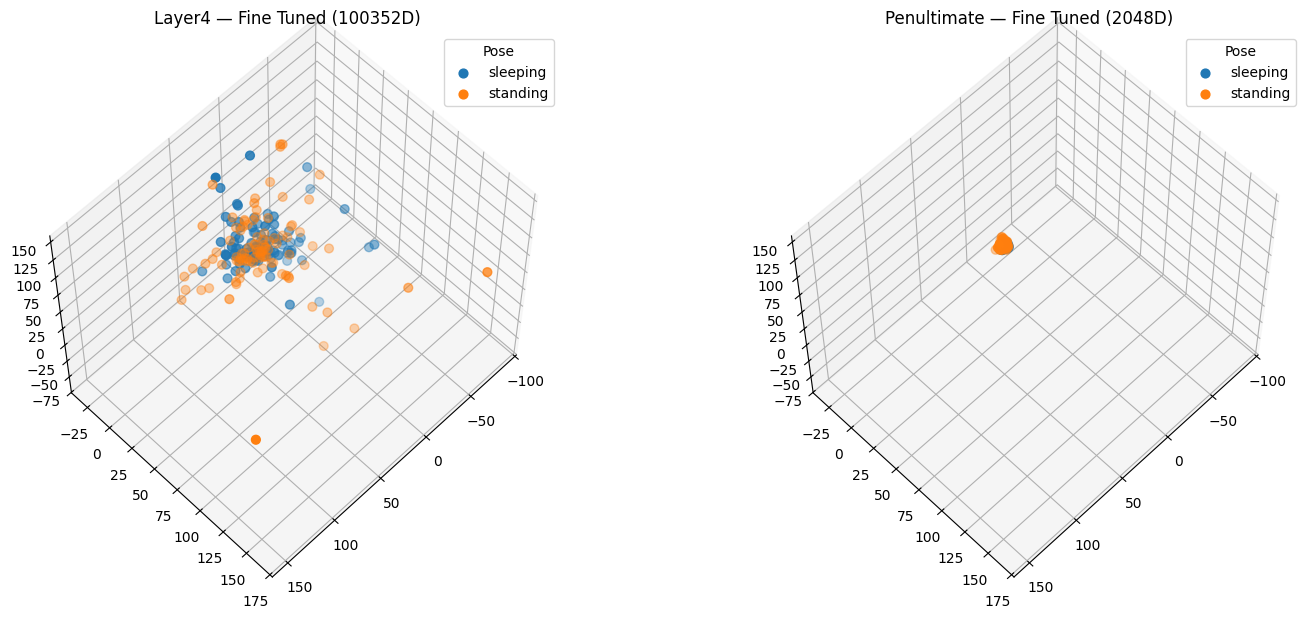

In [30]:
# =========================================================
# FINE TUNED MODEL — PCA Visualization
# Layer4 + Penultimate ONLY
# =========================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image
from sklearn.decomposition import PCA


# -------------------------------
# SETTINGS
# -------------------------------
MODEL_PATH = "resnet50_pose_finetuned.pth"
DATA_FOLDER = "/Users/jaeeponde/Thesis/Pose_100"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -------------------------------
# LOAD MODEL
# -------------------------------
model = models.resnet50(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()


# -------------------------------
# TRANSFORM
# -------------------------------
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])


def load_image(path):
    img = Image.open(path).convert("RGB")
    return transform(img).unsqueeze(0)


# -------------------------------
# LOAD DATASET
# -------------------------------
image_paths = []
image_labels = []

for cls in sorted(os.listdir(DATA_FOLDER)):
    folder = os.path.join(DATA_FOLDER, cls)

    if not os.path.isdir(folder):
        continue

    for f in os.listdir(folder):
        if f.lower().endswith((".jpg",".png",".jpeg")):
            image_paths.append(os.path.join(folder, f))
            image_labels.append(cls.lower())

print("Loaded:", len(image_paths))


# -------------------------------
# STORAGE
# -------------------------------
layer4_outputs = []
penult_outputs = []
labels_store = []

current_label = None


# -------------------------------
# HOOKS
# -------------------------------
def layer4_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1)
    layer4_outputs.append(out.numpy()[0])
    labels_store.append(current_label)


def penult_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1)
    penult_outputs.append(out.numpy()[0])


h1 = model.layer4.register_forward_hook(layer4_hook)
h2 = model.avgpool.register_forward_hook(penult_hook)


# -------------------------------
# FORWARD PASS
# -------------------------------
with torch.no_grad():
    for path, cls in zip(image_paths, image_labels):
        current_label = cls
        img = load_image(path).to(device)
        _ = model(img)

h1.remove()
h2.remove()


# -------------------------------
# ARRAYS
# -------------------------------
layer4_embeddings = np.vstack(layer4_outputs)
penult_embeddings = np.vstack(penult_outputs)

labels = np.array(labels_store)


# -------------------------------
# PCA
# -------------------------------
layer4_pca = PCA(n_components=3)
layer4_3d = layer4_pca.fit_transform(layer4_embeddings)

penult_pca = PCA(n_components=3)
penult_3d = penult_pca.fit_transform(penult_embeddings)


# -------------------------------
# COLORS
# -------------------------------
unique_labels = sorted(set(labels))
color_map = {l:i for i,l in enumerate(unique_labels)}

colors = [color_map[l] for l in labels]


# =========================================================
# PLOT
# =========================================================

fig = plt.figure(figsize=(16,6))

ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')


# Layer4 Plot
for label in unique_labels:
    mask = labels == label

    ax1.scatter(
        layer4_3d[mask,0],
        layer4_3d[mask,1],
        layer4_3d[mask,2],
        label=label,
        s=40
    )

ax1.set_title(f"Layer4 — Fine Tuned ({layer4_embeddings.shape[1]}D)")


# Penultimate Plot
for label in unique_labels:
    mask = labels == label

    ax2.scatter(
        penult_3d[mask,0],
        penult_3d[mask,1],
        penult_3d[mask,2],
        label=label,
        s=40
    )

ax2.set_title(f"Penultimate — Fine Tuned ({penult_embeddings.shape[1]}D)")


# -------------------------------
# Match Axis Scales
# -------------------------------
all_points = np.vstack([layer4_3d, penult_3d])

mins = all_points.min(axis=0)
maxs = all_points.max(axis=0)

for ax in [ax1, ax2]:
    ax.set_xlim(mins[0], maxs[0])
    ax.set_ylim(mins[1], maxs[1])
    ax.set_zlim(mins[2], maxs[2])
    ax.set_box_aspect(maxs - mins)
    ax.view_init(elev=60, azim=45)


ax1.legend(title="Pose")
ax2.legend(title="Pose")

plt.tight_layout()
plt.show()


/var/folders/29/458ydd_j11q4vpw8md8c37fh0000gn/T/ipykernel_38023/494720837.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, 

Loaded: 200


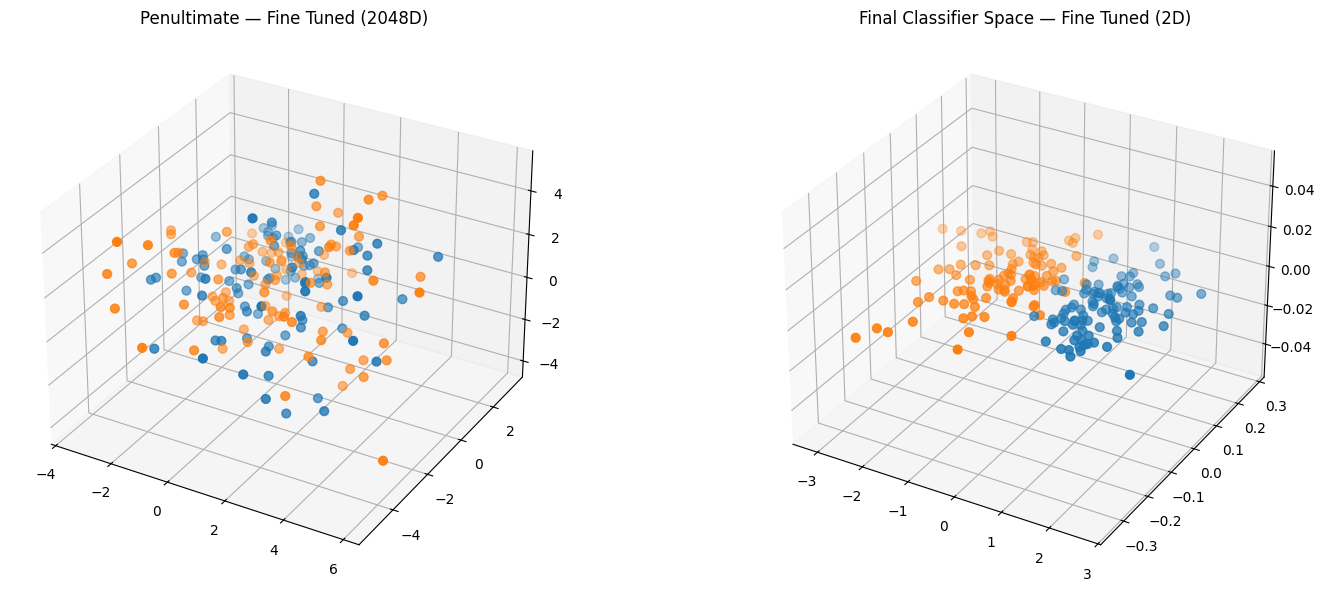

In [38]:
# =========================================================
# FINE TUNED MODEL — PCA
# Penultimate + Final ONLY
# =========================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image
from sklearn.decomposition import PCA


# -------------------------------
# SETTINGS
# -------------------------------
MODEL_PATH = "resnet50_pose_finetuned.pth"
DATA_FOLDER = "/Users/jaeeponde/Thesis/Pose_100"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -------------------------------
# LOAD MODEL
# -------------------------------
model = models.resnet50(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()


# -------------------------------
# TRANSFORM
# -------------------------------
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])


def load_image(path):
    img = Image.open(path).convert("RGB")
    return transform(img).unsqueeze(0)


# -------------------------------
# LOAD DATASET
# -------------------------------
image_paths = []
image_labels = []

for cls in sorted(os.listdir(DATA_FOLDER)):
    folder = os.path.join(DATA_FOLDER, cls)

    if not os.path.isdir(folder):
        continue

    for f in os.listdir(folder):
        if f.lower().endswith((".jpg",".png",".jpeg")):
            image_paths.append(os.path.join(folder, f))
            image_labels.append(cls.lower())

print("Loaded:", len(image_paths))


# -------------------------------
# STORAGE
# -------------------------------
penult_outputs = []
final_outputs = []
labels_store = []

current_label = None


# -------------------------------
# HOOKS
# -------------------------------
def penult_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1)
    penult_outputs.append(out.numpy()[0])
    labels_store.append(current_label)


def final_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1)
    final_outputs.append(out.numpy()[0])


h1 = model.avgpool.register_forward_hook(penult_hook)
h2 = model.fc.register_forward_hook(final_hook)


# -------------------------------
# FORWARD PASS
# -------------------------------
with torch.no_grad():
    for path, cls in zip(image_paths, image_labels):
        current_label = cls
        img = load_image(path).to(device)
        _ = model(img)

h1.remove()
h2.remove()


# -------------------------------
# ARRAYS
# -------------------------------
penult_embeddings = np.vstack(penult_outputs)
final_embeddings = np.vstack(final_outputs)

labels = np.array(labels_store)


# -------------------------------
# PCA
# -------------------------------
penult_pca = PCA(n_components=3)
penult_3d = penult_pca.fit_transform(penult_embeddings)
final_pca = PCA(n_components=2)
final_2d = final_pca.fit_transform(final_embeddings)


# -------------------------------
# COLORS
# -------------------------------
unique_labels = sorted(set(labels))


# =========================================================
# PLOT
# =========================================================

fig = plt.figure(figsize=(16,6))

ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')


# Penultimate Plot
for label in unique_labels:
    mask = labels == label
    ax1.scatter(
        penult_3d[mask,0],
        penult_3d[mask,1],
        penult_3d[mask,2],
        label=label,
        s=40
    )

ax1.set_title(f"Penultimate — Fine Tuned ({penult_embeddings.shape[1]}D)")


# Final Plot
for label in unique_labels:
    mask = labels == label
    ax2.scatter(
        final_2d[mask,0],
        final_2d[mask,1],
        label=label,
        s=40
    )

ax2.set_title(f"Final Classifier Space — Fine Tuned ({final_embeddings.shape[1]}D)")


# -------------------------------
# Match Axes
# -------------------------------


plt.tight_layout()
plt.show()


/var/folders/29/458ydd_j11q4vpw8md8c37fh0000gn/T/ipykernel_38023/480823133.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, 

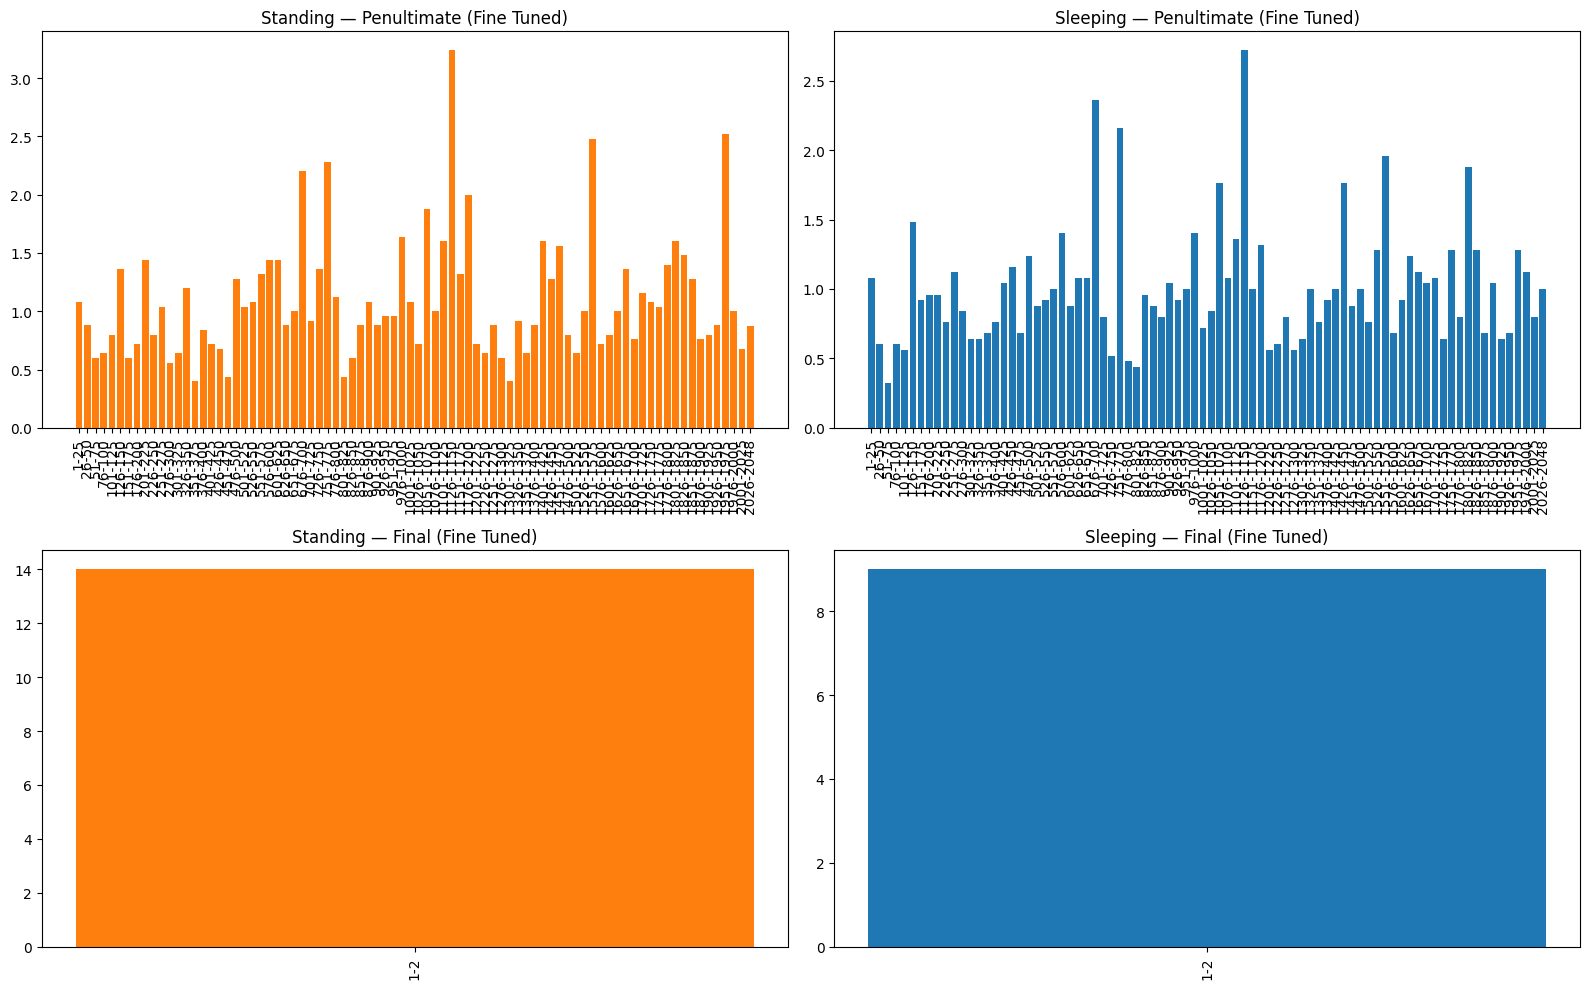

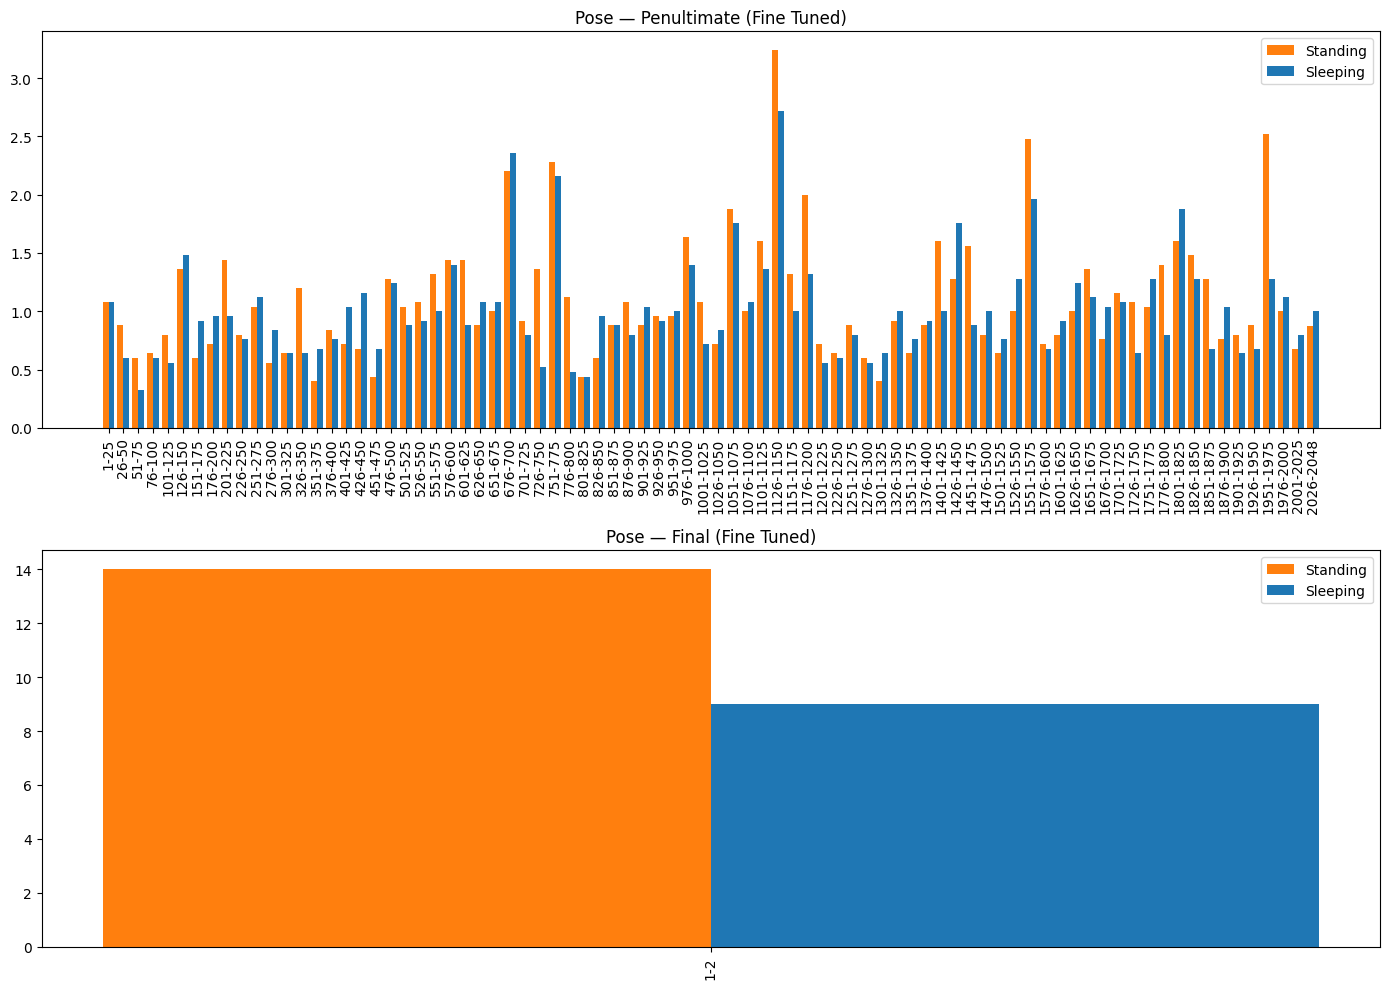

In [39]:
# =========================================================
# BAR PLOTS — FINE TUNED RESNET50 (POSE MODEL)
# =========================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image


# -------------------------------
# SETTINGS
# -------------------------------
MODEL_PATH = "resnet50_pose_finetuned.pth"
POSE_FOLDER = "/Users/jaeeponde/Thesis/Pose_100"

THRESHOLD = 1.0
GROUP_SIZE = 25

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -------------------------------
# LOAD MODEL
# -------------------------------
model = models.resnet50(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()


# -------------------------------
# TRANSFORM
# -------------------------------
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])


def load_image(path):
    img = Image.open(path).convert("RGB")
    return transform(img).unsqueeze(0)


# -------------------------------
# LOAD POSE DATA
# -------------------------------
image_paths = []
image_labels = []

for label in ["Standing", "Sleeping"]:
    folder = os.path.join(POSE_FOLDER, label)

    for f in os.listdir(folder):
        if f.lower().endswith((".jpg",".png",".jpeg")):
            image_paths.append(os.path.join(folder, f))
            image_labels.append(label.lower())


# -------------------------------
# STORAGE
# -------------------------------
penult_standing = []
penult_sleeping = []

final_standing = []
final_sleeping = []

current_label = None


# -------------------------------
# HOOKS
# -------------------------------
def penultimate_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1).numpy()[0]

    if current_label == "standing":
        penult_standing.append(out)
    else:
        penult_sleeping.append(out)


def final_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1).numpy()[0]

    if current_label == "standing":
        final_standing.append(out)
    else:
        final_sleeping.append(out)


h1 = model.avgpool.register_forward_hook(penultimate_hook)
h2 = model.fc.register_forward_hook(final_hook)


# -------------------------------
# FORWARD PASS
# -------------------------------
with torch.no_grad():
    for path, cls in zip(image_paths, image_labels):
        current_label = cls
        img = load_image(path).to(device)
        _ = model(img)

h1.remove()
h2.remove()


# -------------------------------
# ARRAYS
# -------------------------------
penult_standing = np.vstack(penult_standing)
penult_sleeping = np.vstack(penult_sleeping)

final_standing = np.vstack(final_standing)
final_sleeping = np.vstack(final_sleeping)


# -------------------------------
# GROUPING
# -------------------------------
def group_neurons(freq_array, group_size):
    return np.array([
        freq_array[i:i+group_size].mean()
        for i in range(0, len(freq_array), group_size)
    ])


def make_labels(n_neurons, group_size):
    return [
        f"{i+1}-{min(i+group_size,n_neurons)}"
        for i in range(0, n_neurons, group_size)
    ]


# -------------------------------
# FREQUENCIES
# -------------------------------
penult_stand_freq = (penult_standing > THRESHOLD).sum(axis=0)
penult_sleep_freq = (penult_sleeping > THRESHOLD).sum(axis=0)

final_stand_freq = (final_standing > THRESHOLD).sum(axis=0)
final_sleep_freq = (final_sleeping > THRESHOLD).sum(axis=0)


penult_stand_grp = group_neurons(penult_stand_freq, GROUP_SIZE)
penult_sleep_grp = group_neurons(penult_sleep_freq, GROUP_SIZE)

final_stand_grp = group_neurons(final_stand_freq, GROUP_SIZE)
final_sleep_grp = group_neurons(final_sleep_freq, GROUP_SIZE)


penult_labels = make_labels(len(penult_stand_freq), GROUP_SIZE)
final_labels = make_labels(len(final_stand_freq), GROUP_SIZE)


# =========================================================
# NON OVERLAY
# =========================================================
plt.figure(figsize=(16,10))

plt.subplot(2,2,1)
plt.bar(range(len(penult_stand_grp)), penult_stand_grp, color="tab:orange")
plt.xticks(range(len(penult_labels)), penult_labels, rotation=90)
plt.title("Standing — Penultimate (Fine Tuned)")

plt.subplot(2,2,2)
plt.bar(range(len(penult_sleep_grp)), penult_sleep_grp, color="tab:blue")
plt.xticks(range(len(penult_labels)), penult_labels, rotation=90)
plt.title("Sleeping — Penultimate (Fine Tuned)")

plt.subplot(2,2,3)
plt.bar(range(len(final_stand_grp)), final_stand_grp, color="tab:orange")
plt.xticks(range(len(final_labels)), final_labels, rotation=90)
plt.title("Standing — Final (Fine Tuned)")

plt.subplot(2,2,4)
plt.bar(range(len(final_sleep_grp)), final_sleep_grp, color="tab:blue")
plt.xticks(range(len(final_labels)), final_labels, rotation=90)
plt.title("Sleeping — Final (Fine Tuned)")

plt.tight_layout()
plt.show()


# =========================================================
# OVERLAY
# =========================================================
plt.figure(figsize=(14,10))

bar_width = 0.4
x_penult = np.arange(len(penult_stand_grp))
x_final = np.arange(len(final_stand_grp))

plt.subplot(2,1,1)
plt.bar(x_penult-bar_width/2, penult_stand_grp, width=bar_width, color="tab:orange", label="Standing")
plt.bar(x_penult+bar_width/2, penult_sleep_grp, width=bar_width, color="tab:blue", label="Sleeping")
plt.xticks(x_penult, penult_labels, rotation=90)
plt.title("Pose — Penultimate (Fine Tuned)")
plt.legend()

plt.subplot(2,1,2)
plt.bar(x_final-bar_width/2, final_stand_grp, width=bar_width, color="tab:orange", label="Standing")
plt.bar(x_final+bar_width/2, final_sleep_grp, width=bar_width, color="tab:blue", label="Sleeping")
plt.xticks(x_final, final_labels, rotation=90)
plt.title("Pose — Final (Fine Tuned)")
plt.legend()

plt.tight_layout()
plt.show()
